# MNIST MLP3 — AdamW horizon-optimized baseline

Runs a separate 30-epoch AdamW candidate in `adamw_horizon_optimized`. The recipe lowers peak LR, lowers the floor, extends warm-up, and increases matrix-only decoupled weight decay to target validation cross-entropy over this fixed horizon. The official test set remains monitoring-only.

In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    BaselineConfig,
    DEFAULT_BASELINE_SEEDS,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
    plot_all_replicates,
    run_baseline_replicates,
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

BASE_RUN_ROOT = Path(os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
DATA_DIR = Path(os.environ.get('RG_BASELINE_DATA_DIR', ROOT / 'data')).expanduser().resolve()
for directory in (BASE_RUN_ROOT, RUN_ROOT, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('versioned suite root:', RUN_ROOT)


versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3


In [2]:
CONFIG = BaselineConfig(
    optimizer='adamw',
    epochs=30,
    validation_size=5_000,
    adamw_learning_rate=5e-4,
    adamw_min_learning_rate=1e-6,
    adamw_warmup_epochs=2,
    adamw_beta1=0.90,
    adamw_beta2=0.999,
    adamw_weight_decay=3e-2,
    ww_randomize=True,
    save_epoch_checkpoints=True,
)
CONFIG.validate()
if CONFIG.recipe_version != MNIST_REFERENCE_RECIPE_VERSION:
    raise RuntimeError('Notebook expects current MNIST recipe version.')
SEEDS = DEFAULT_BASELINE_SEEDS
assert len(SEEDS) == 3 and len(set(SEEDS)) == 3
RUN_DIR = RUN_ROOT / 'adamw_horizon_optimized'
PLOT_DIR = RUN_DIR / 'plots'
for directory in (RUN_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('optimizer implementation:', CONFIG.optimizer_label)
print('horizon-optimized run directory:', RUN_DIR)
display(pd.DataFrame([CONFIG.__dict__]))


optimizer implementation: AdamW
horizon-optimized run directory: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/adamw_horizon_optimized


,optimizer,recipe_version,initialization,seed,epochs,batch_size,validation_size,split_seed,num_workers,grad_clip_norm,train_eval_max_batches,schedule,checkpoint_every_epochs,test_monitoring_only,sgd_learning_rate,sgd_min_learning_rate,sgd_warmup_epochs,sgd_momentum,sgd_dampening,sgd_nesterov,sgd_weight_decay,adamw_learning_rate,adamw_min_learning_rate,adamw_warmup_epochs,adamw_beta1,adamw_beta2,adamw_eps,adamw_weight_decay,adamw_amsgrad,muon_parameter_names,muon_learning_rate,muon_min_learning_rate,muon_warmup_epochs,muon_momentum,muon_nesterov,muon_weight_decay,muon_newton_schulz_steps,muon_eps,muon_aux_learning_rate,muon_aux_min_learning_rate,muon_aux_beta1,muon_aux_beta2,muon_aux_eps,muon_aux_weight_decay,ww_min_evals,ww_max_evals,ww_svd_method,ww_randomize,save_epoch_checkpoints,strict_metrics
0,adamw,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0005,0.000001,2,0.9,0.999,1.000000e-08,0.03,False,"(fc1.weight, fc2.weight)",0.02,0.002,2,0.95,True,0.01,5,1.000000e-07,0.0003,0.00003,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True



=== AdamW: replicate 1/3, seed=1337 ===


PyTorch is available but CUDA is not. Defaulting to NumPy for SVD


Import error , reetting to svd accurate methods


Running on macOS.
Running on macOS.


SMALL N PL FIT


...

epoch=028 | AdamW | lr=7.257e-06 | train=1.0000 | val=0.9860 | test=0.9844


SMALL N PL FIT


epoch=029 | AdamW | lr=2.569e-06 | train=1.0000 | val=0.9860 | test=0.9844


SMALL N PL FIT


epoch=030 | AdamW | lr=1.000e-06 | train=1.0000 | val=0.9860 | test=0.9843


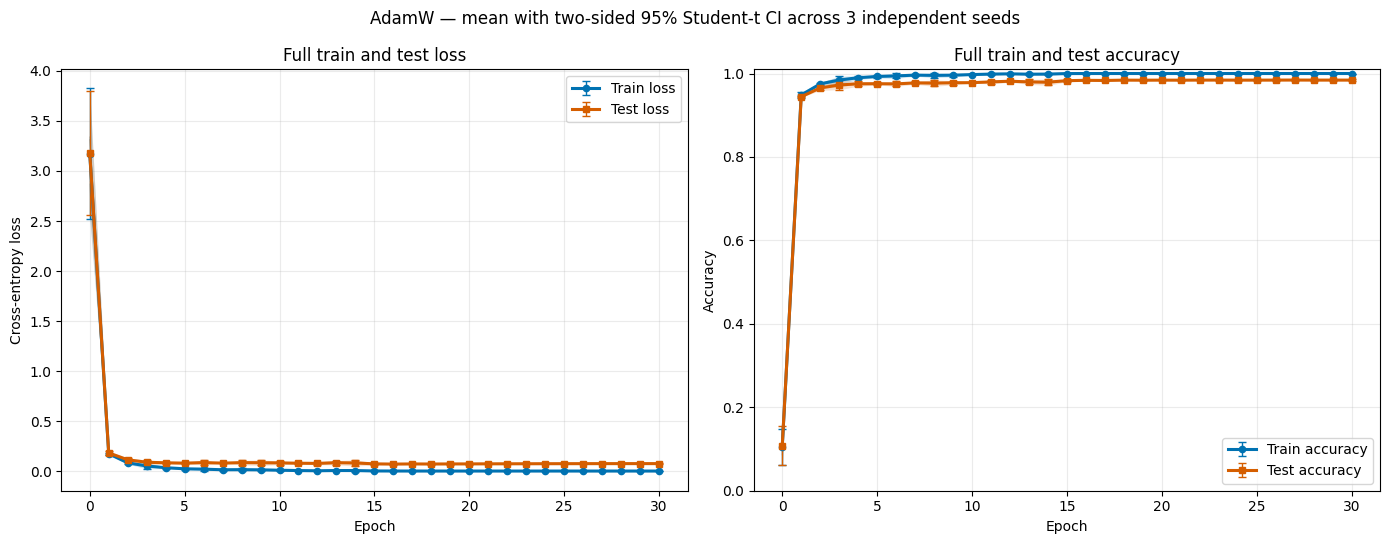

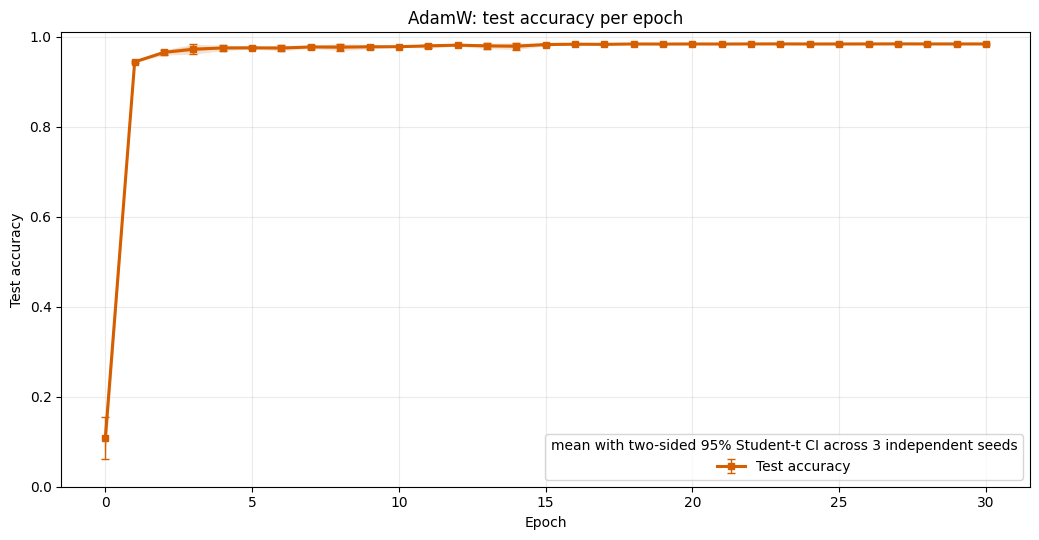

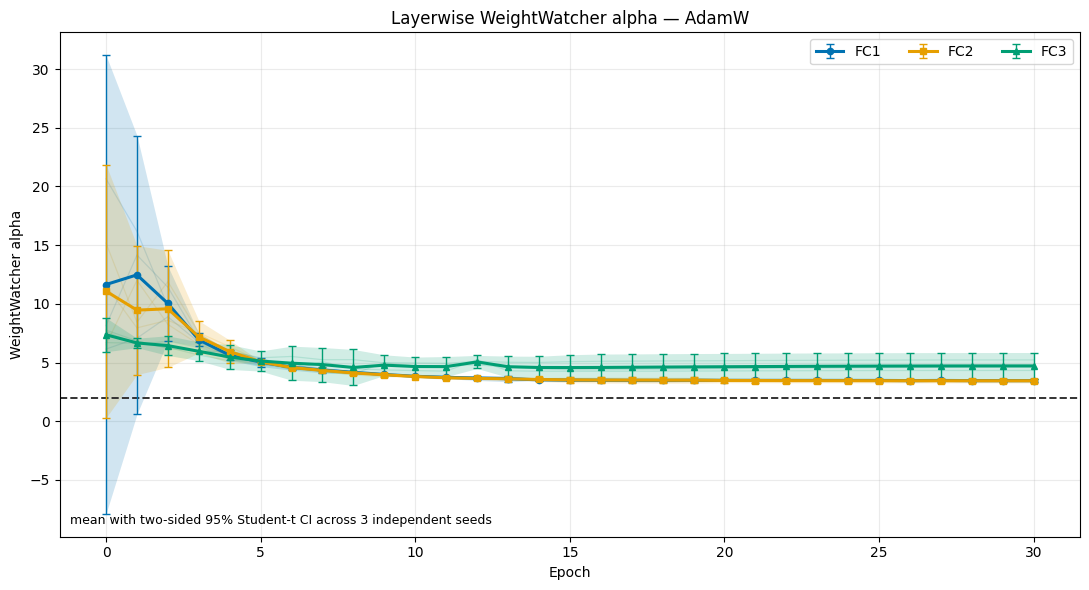

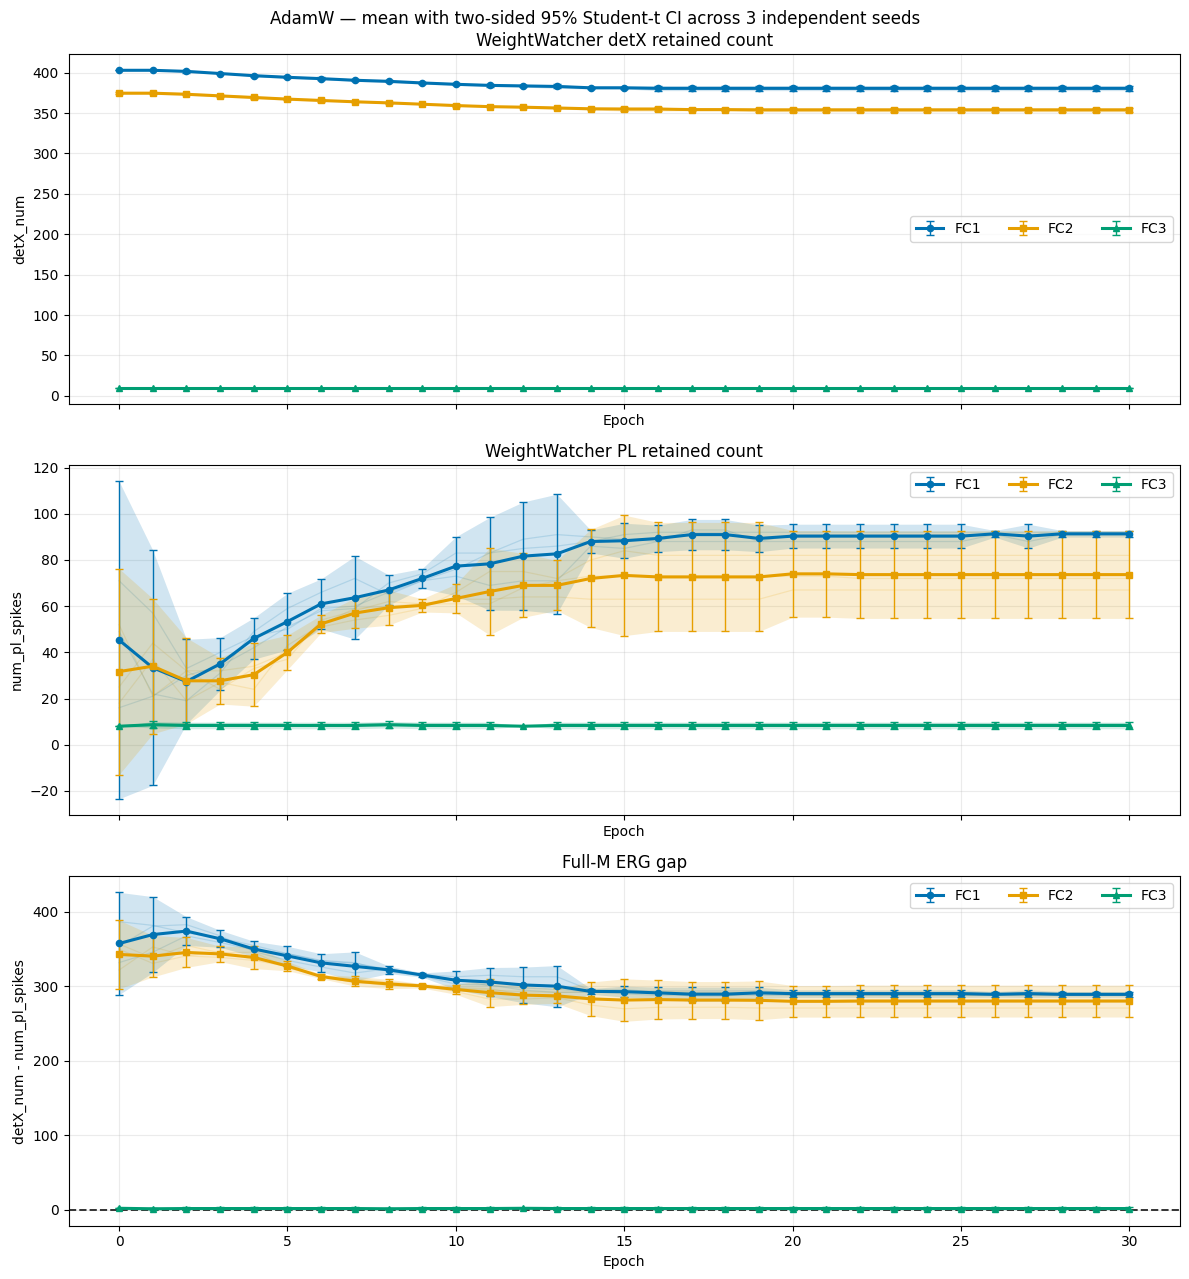

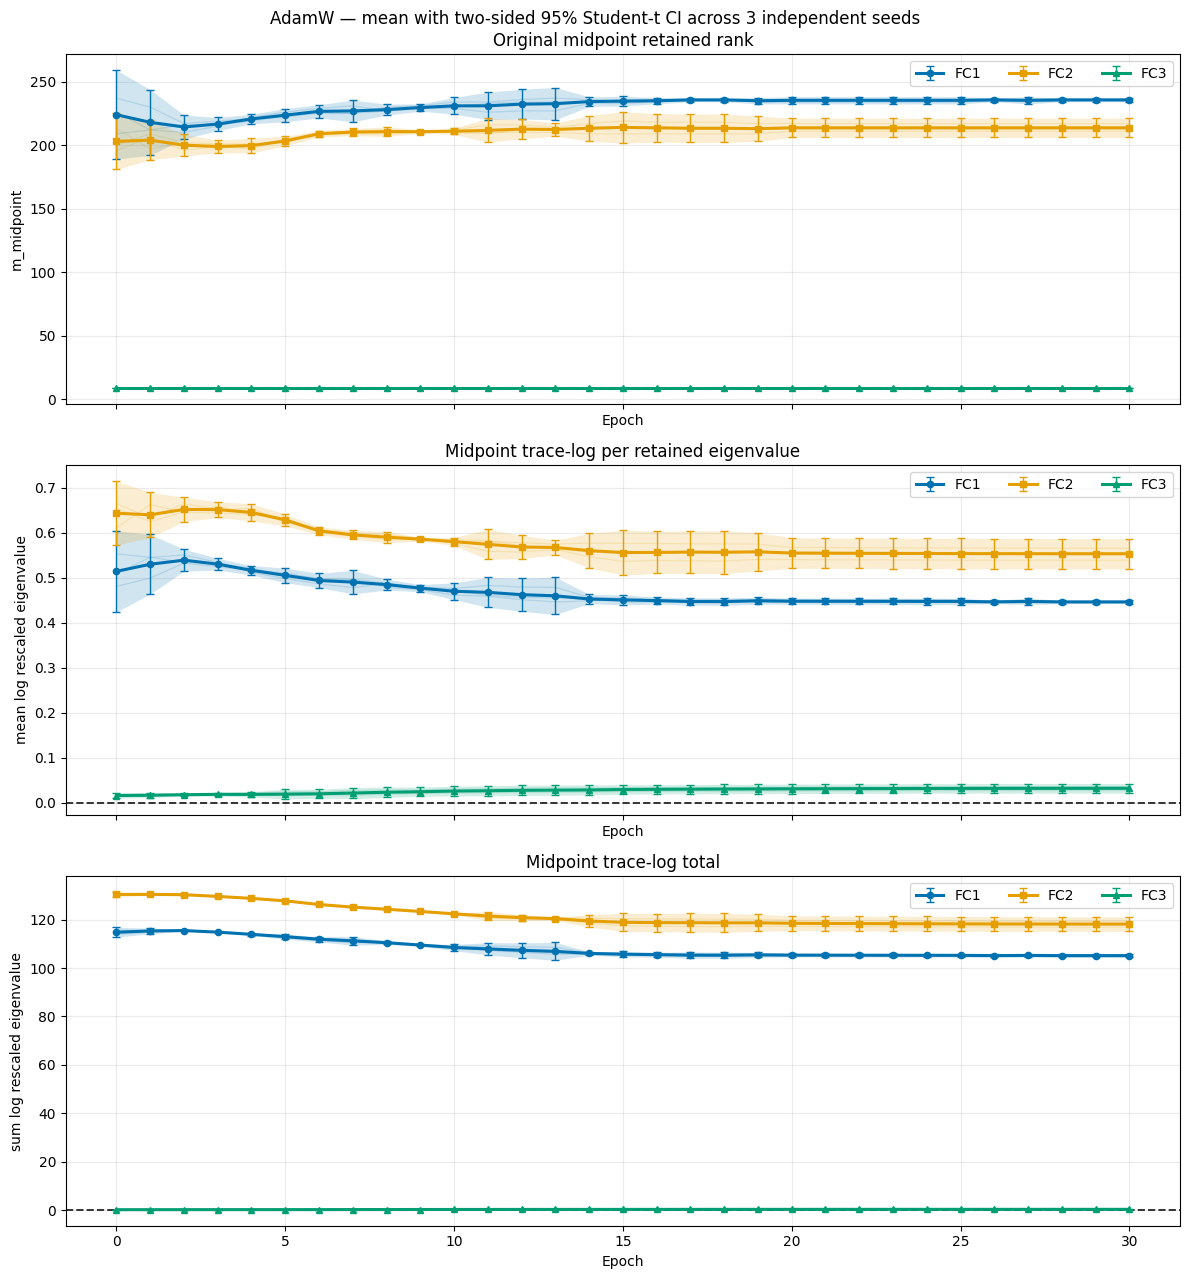

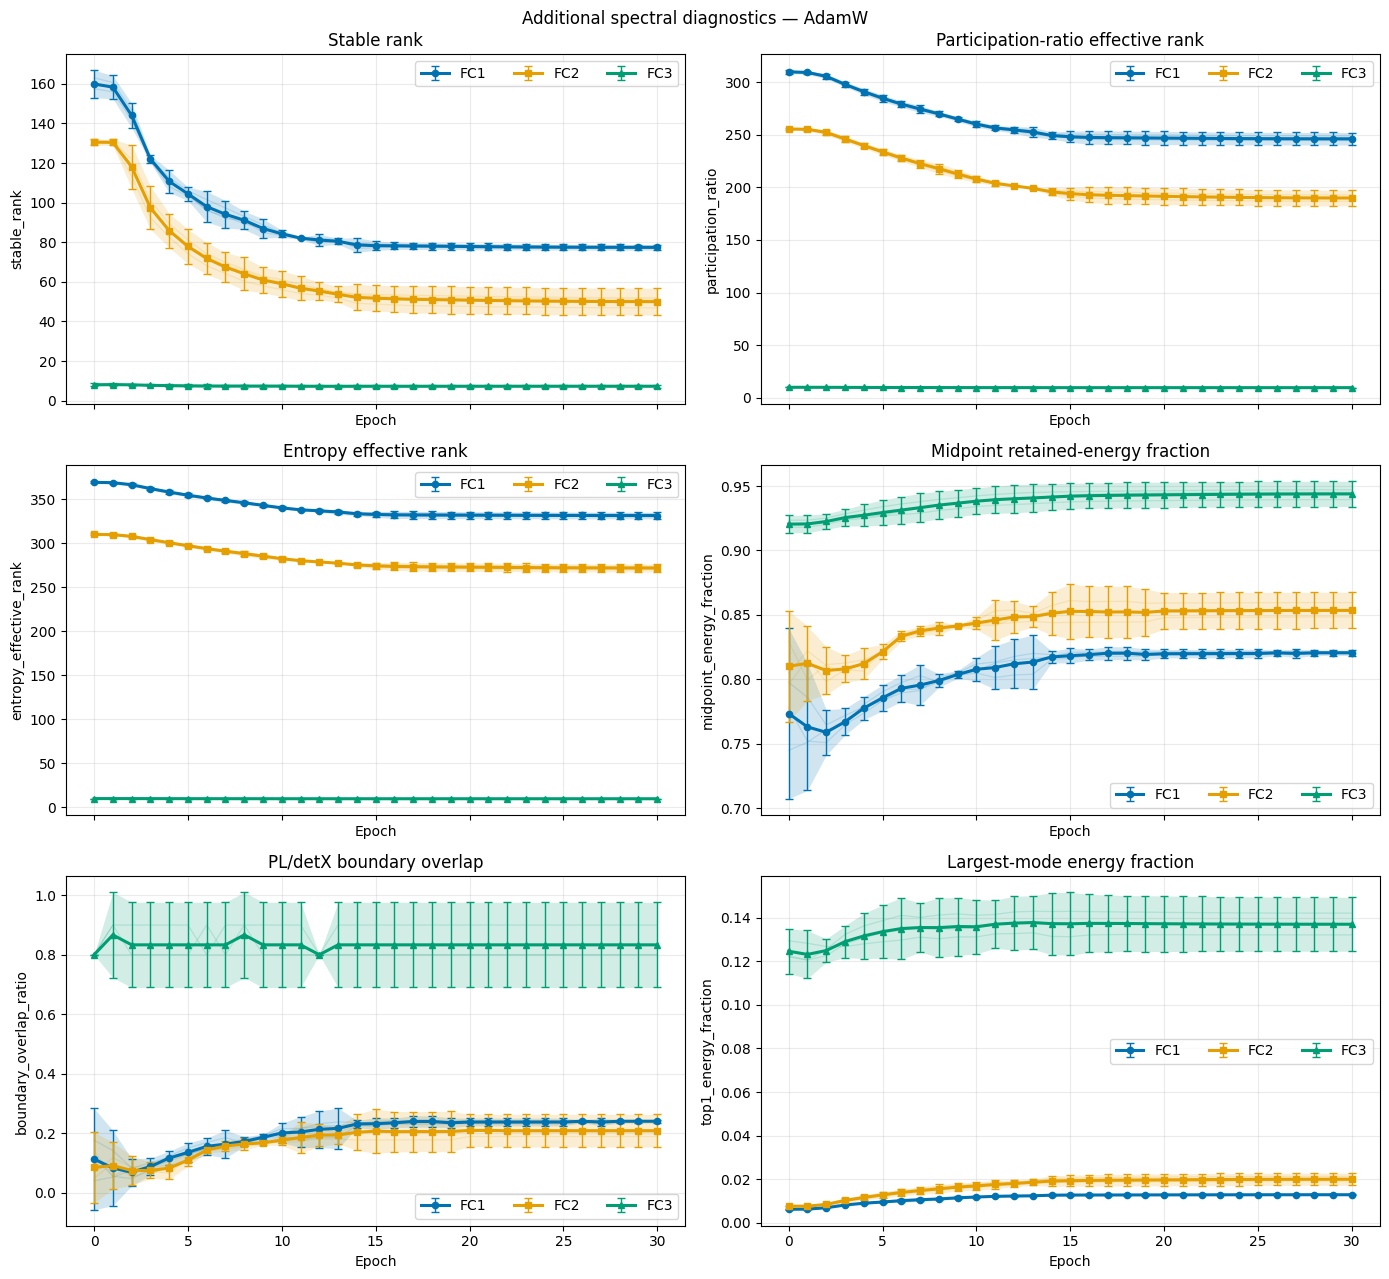

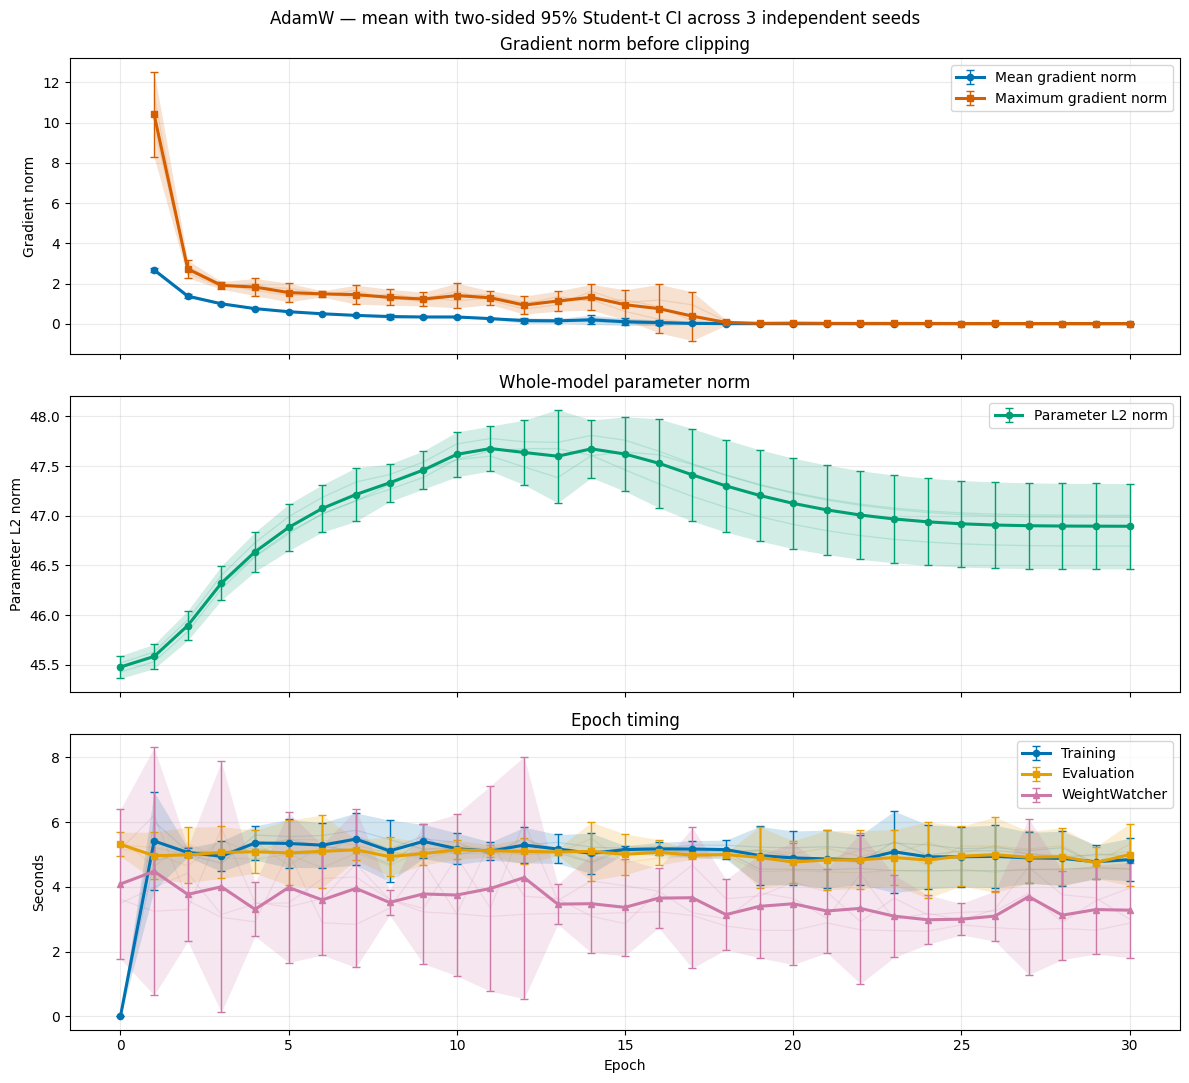

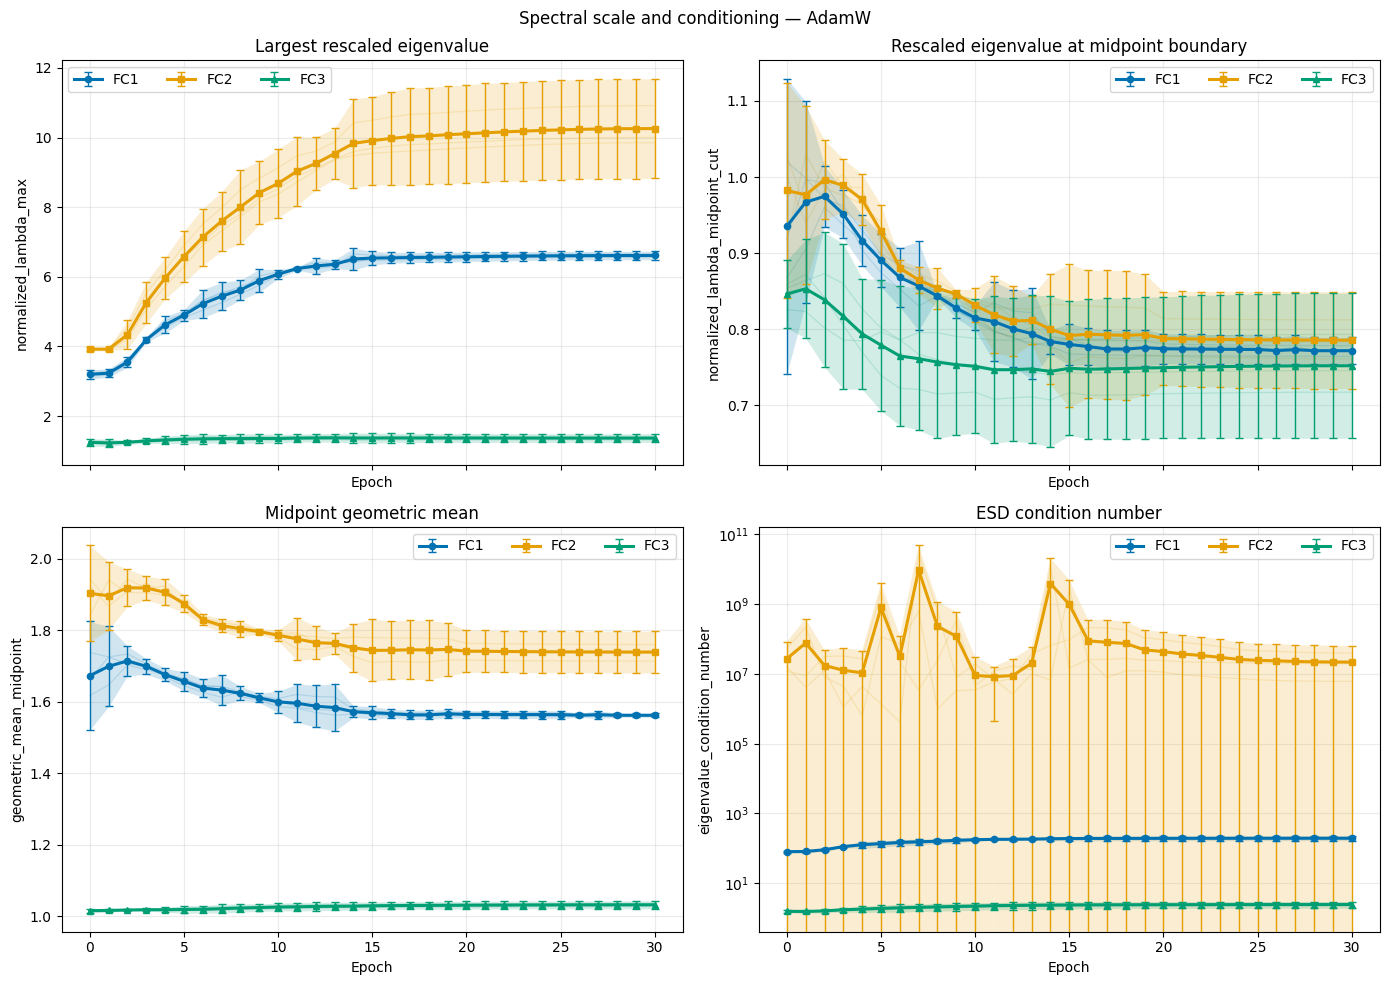

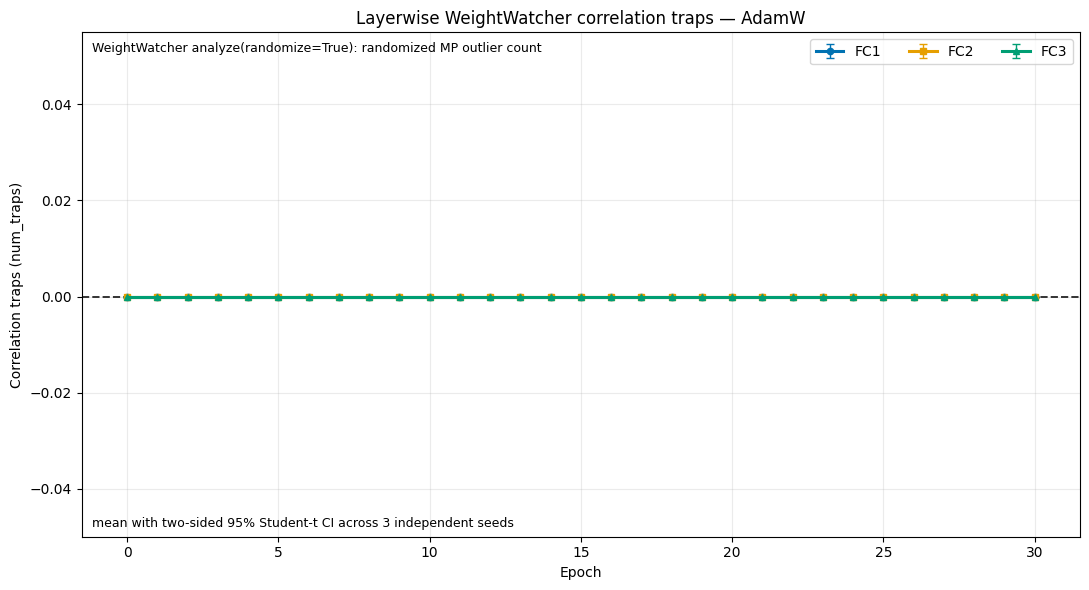

[<Figure size 1400x550 with 2 Axes>,
 <Figure size 1050x550 with 1 Axes>,
 <Figure size 1100x600 with 1 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1400x1300 with 6 Axes>,
 <Figure size 1200x1100 with 3 Axes>,
 <Figure size 1400x1000 with 4 Axes>,
 <Figure size 1100x600 with 1 Axes>]

In [3]:
suite = run_baseline_replicates(
    CONFIG,
    seeds=SEEDS,
    data_dir=DATA_DIR,
    output_dir=RUN_DIR,
    progress=True,
    confidence=0.95,
    resume=True,
    overwrite=False,
)
assert suite.config_template.recipe_version == MNIST_REFERENCE_RECIPE_VERSION
plot_all_replicates(suite, output_dir=PLOT_DIR, show=True)


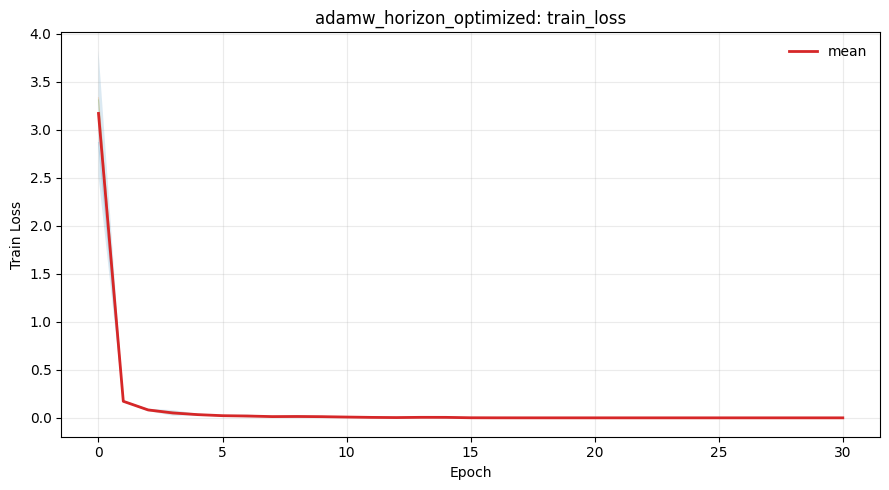

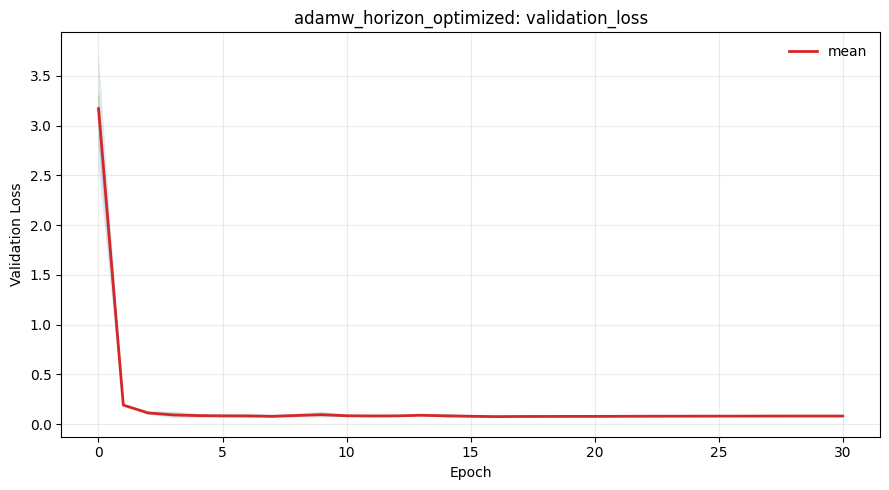

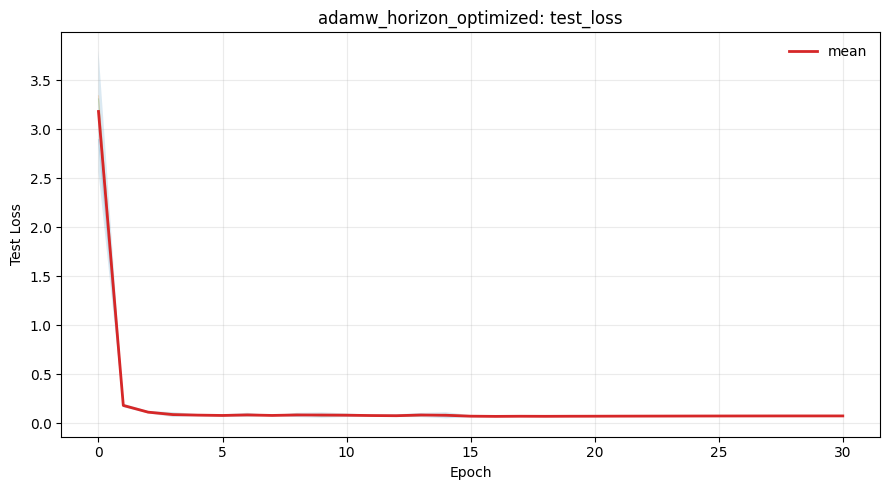

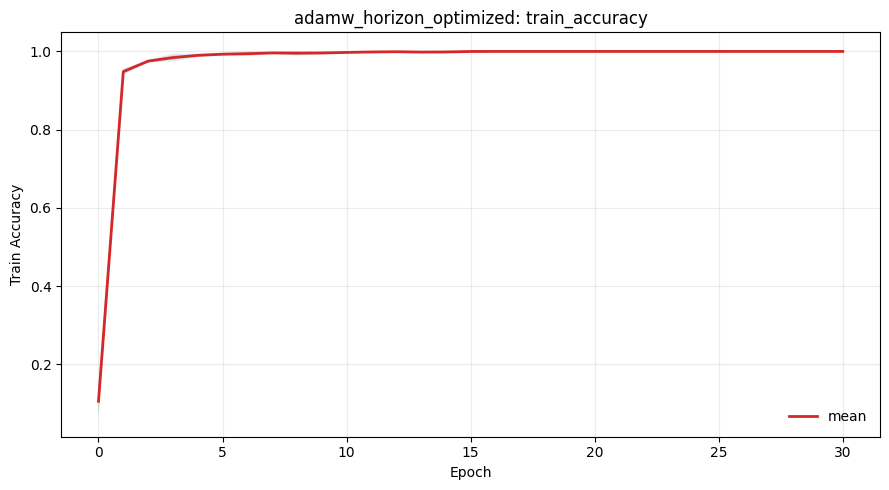

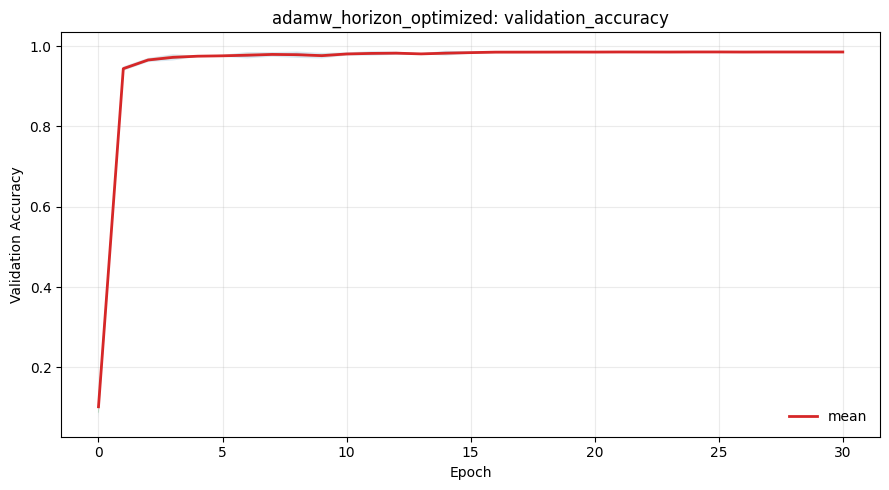

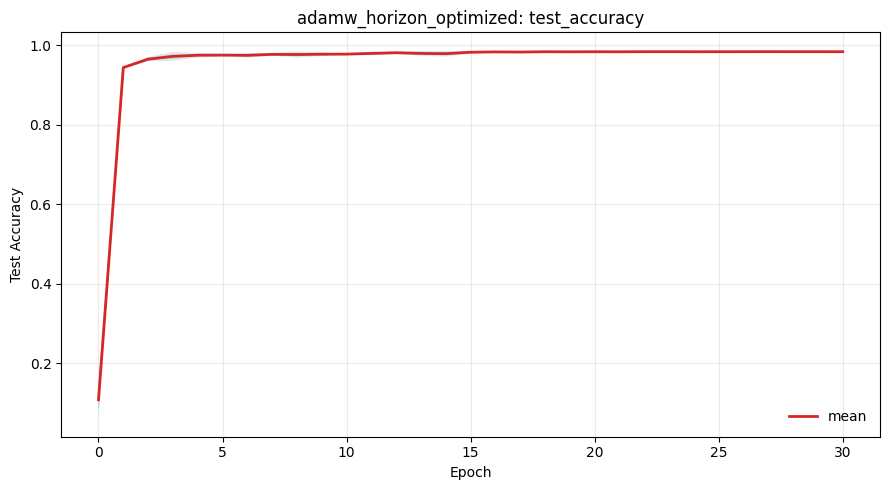

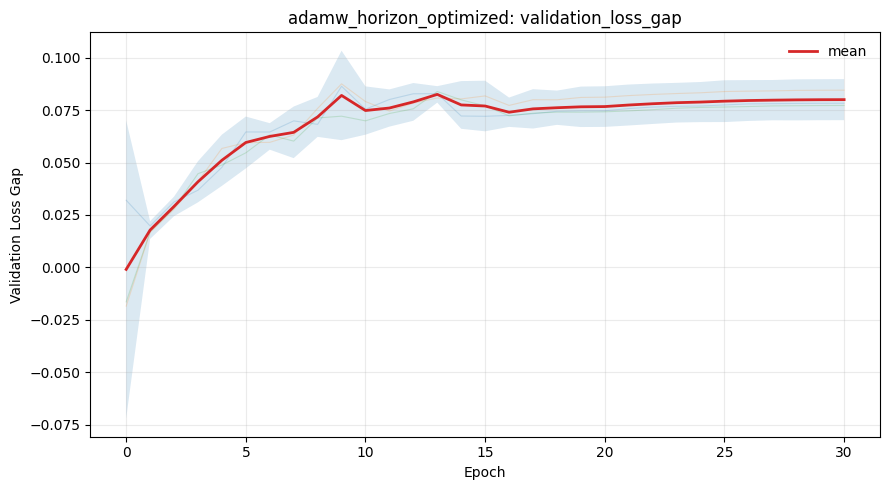

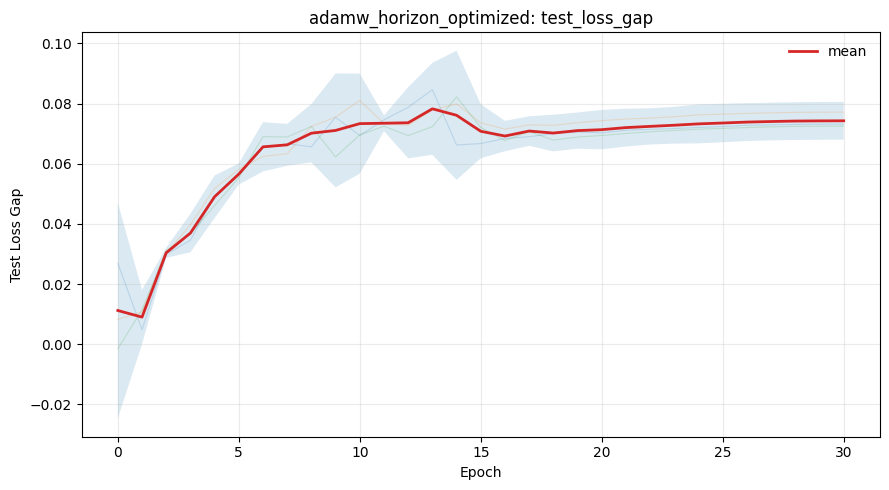

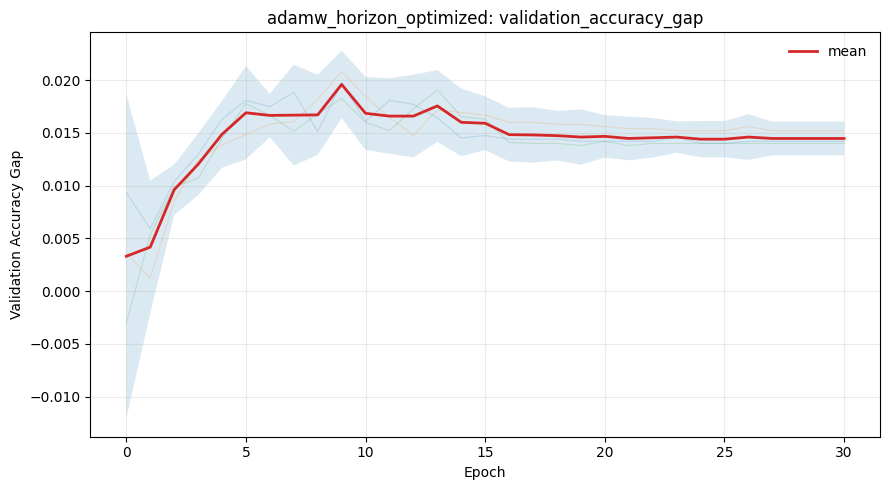

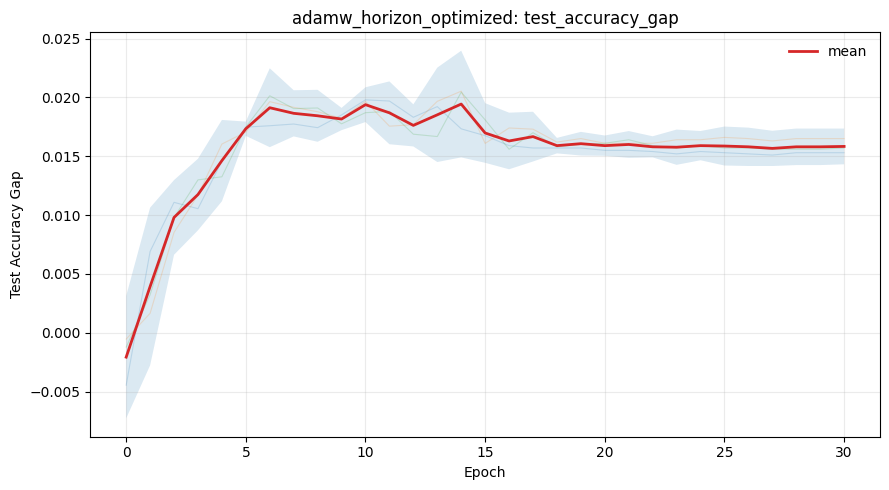

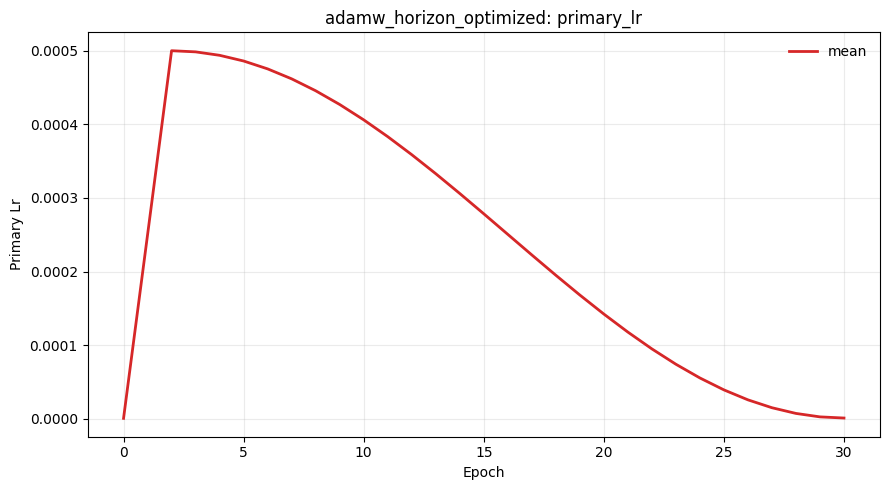

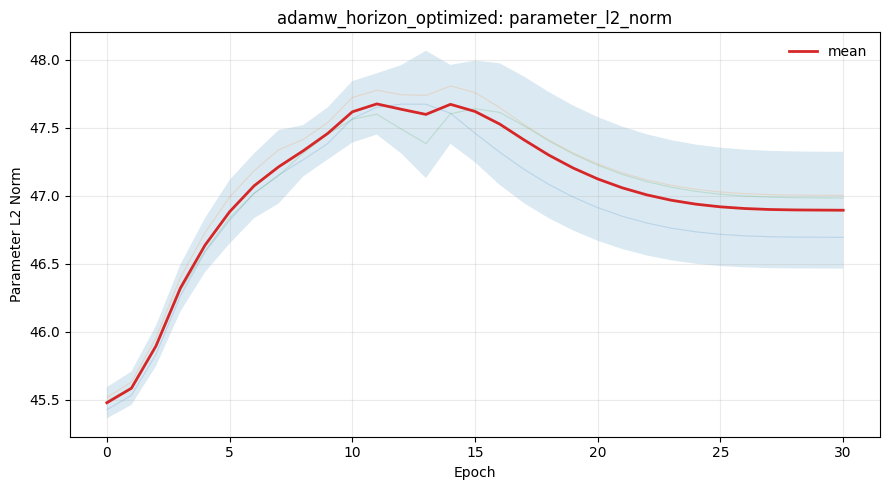

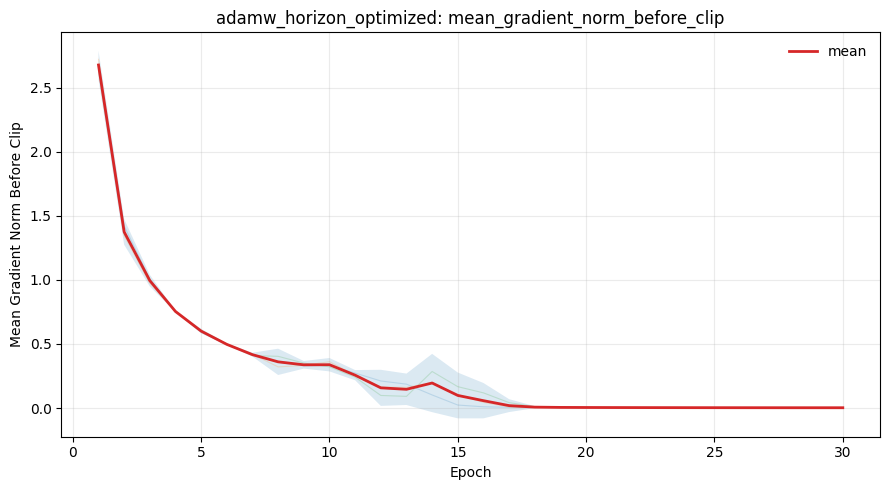

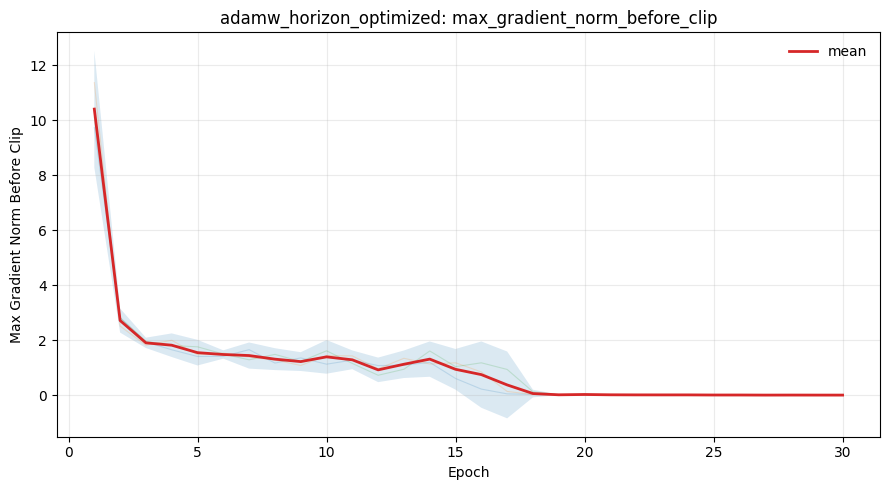

,run,optimizer,optimizer_label,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
31,AdamW,adamw,AdamW,1,max_gradient_norm_before_clip,3,1.040854e+01,8.545150e-01,4.933545e-01,0.95,4.302653,2.122733e+00,8.285810e+00,1.253128e+01,9.742595e+00,1.137206e+01
52,AdamW,adamw,AdamW,2,max_gradient_norm_before_clip,3,2.721264e+00,1.762444e-01,1.017547e-01,0.95,4.302653,4.378153e-01,2.283449e+00,3.159080e+00,2.517770e+00,2.825181e+00
73,AdamW,adamw,AdamW,3,max_gradient_norm_before_clip,3,1.909562e+00,7.556709e-02,4.362868e-02,0.95,4.302653,1.877191e-01,1.721843e+00,2.097281e+00,1.823723e+00,1.966051e+00
94,AdamW,adamw,AdamW,4,max_gradient_norm_before_clip,3,1.824204e+00,1.727347e-01,9.972843e-02,0.95,4.302653,4.290968e-01,1.395107e+00,2.253301e+00,1.658244e+00,2.002998e+00
115,AdamW,adamw,AdamW,5,max_gradient_norm_before_clip,3,1.552762e+00,1.874686e-01,1.082350e-01,0.95,4.302653,4.656977e-01,1.087064e+00,2.018460e+00,1.413056e+00,1.765815e+00
136,AdamW,adamw,AdamW,6,max_gradient_norm_before_clip,3,1.486126e+00,6.111730e-02,3.528609e-02,0.95,4.302653,1.518238e-01,1.334303e+00,1.637950e+00,1.418679e+00,1.537834e+00
157,AdamW,adamw,AdamW,7,max_gradient_norm_before_clip,3,1.447814e+00,1.913631e-01,1.104835e-01,0.95,4.302653,4.753722e-01,9.724416e-01,1.923186e+00,1.292950e+00,1.661747e+00
178,AdamW,adamw,AdamW,8,max_gradient_norm_before_clip,3,1.316933e+00,1.599670e-01,9.235701e-02,0.95,4.302653,3.973801e-01,9.195533e-01,1.714314e+00,1.174772e+00,1.490152e+00
199,AdamW,adamw,AdamW,9,max_gradient_norm_before_clip,3,1.227890e+00,1.373813e-01,7.931713e-02,0.95,4.302653,3.412741e-01,8.866161e-01,1.569164e+00,1.088106e+00,1.362735e+00
220,AdamW,adamw,AdamW,10,max_gradient_norm_before_clip,3,1.400156e+00,2.463125e-01,1.422086e-01,0.95,4.302653,6.118741e-01,7.882820e-01,2.012030e+00,1.134101e+00,1.620252e+00


In [4]:
metrics = [
    'train_loss', 'validation_loss', 'test_loss',
    'train_accuracy', 'validation_accuracy', 'test_accuracy',
    'validation_loss_gap', 'test_loss_gap',
    'validation_accuracy_gap', 'test_accuracy_gap',
    'primary_lr', 'auxiliary_lr', 'parameter_l2_norm',
    'mean_gradient_norm_before_clip', 'max_gradient_norm_before_clip',
]
for metric in metrics:
    if metric not in suite.performance.columns:
        continue
    summary = suite.performance_summary[suite.performance_summary['metric'].eq(metric)].sort_values('epoch')
    if summary.empty:
        continue
    figure, axis = plt.subplots(figsize=(9, 5))
    for seed, run in suite.performance.groupby('seed'):
        axis.plot(run['epoch'], run[metric], alpha=0.18, linewidth=0.8)
    axis.plot(summary['epoch'], summary['mean'], linewidth=2.0, label='mean')
    axis.fill_between(summary['epoch'], summary['ci_low'], summary['ci_high'], alpha=0.16)
    axis.set(xlabel='Epoch', ylabel=metric.replace('_', ' ').title(), title=f'{RUN_DIR.name}: {metric}')
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
    figure.tight_layout()
    figure.savefig(PLOT_DIR / f'{metric}_95ci.png', dpi=170, bbox_inches='tight')
    plt.show()

display(suite.performance_summary[suite.performance_summary['metric'].isin(metrics)].sort_values(['metric', 'epoch']))


In [5]:
required = [
    'alpha', 'ERG_gap', 'num_traps', 'm_midpoint',
    'trace_log_midpoint_per_eval', 'stable_rank',
    'normalized_lambda_max',
]
rows = suite.spectral_summary[suite.spectral_summary['metric'].isin(required)].sort_values(['metric', 'layer', 'epoch'])
assert rows['n'].eq(3).all()
display(rows)


,run,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,AdamW,adamw,AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
33,AdamW,adamw,AdamW,fc1,1,ERG_gap,3,369.666667,20.502032,11.836854,0.95,4.302653,50.929872,318.736795,420.596539,346.000000,382.000000
62,AdamW,adamw,AdamW,fc1,2,ERG_gap,3,374.333333,7.767453,4.484541,0.95,4.302653,19.295424,355.037909,393.628757,368.000000,383.000000
91,AdamW,adamw,AdamW,fc1,3,ERG_gap,3,364.000000,4.582576,2.645751,0.95,4.302653,11.383749,352.616251,375.383749,359.000000,368.000000
120,AdamW,adamw,AdamW,fc1,4,ERG_gap,3,350.333333,4.163332,2.403701,0.95,4.302653,10.342290,339.991043,360.675623,347.000000,355.000000
149,AdamW,adamw,AdamW,fc1,5,ERG_gap,3,341.000000,5.196152,3.000000,0.95,4.302653,12.907958,328.092042,353.907958,335.000000,344.000000
178,AdamW,adamw,AdamW,fc1,6,ERG_gap,3,331.666667,4.932883,2.848001,0.95,4.302653,12.253960,319.412706,343.920627,326.000000,335.000000
207,AdamW,adamw,AdamW,fc1,7,ERG_gap,3,327.000000,7.810250,4.509250,0.95,4.302653,19.401736,307.598264,346.401736,318.000000,332.000000
236,AdamW,adamw,AdamW,fc1,8,ERG_gap,3,322.333333,2.081666,1.201850,0.95,4.302653,5.171145,317.162188,327.504478,320.000000,324.000000
265,AdamW,adamw,AdamW,fc1,9,ERG_gap,3,315.333333,1.154701,0.666667,0.95,4.302653,2.868435,312.464898,318.201768,314.000000,316.000000


In [6]:
required_paths = [
    RUN_DIR / 'performance_by_epoch_and_seed.csv',
    RUN_DIR / 'spectral_metrics_by_epoch_layer_and_seed.csv',
    RUN_DIR / 'performance_summary_95ci.csv',
    RUN_DIR / 'spectral_summary_95ci.csv',
    RUN_DIR / 'replicate_manifest.json',
]
for seed in SEEDS:
    seed_dir = RUN_DIR / 'seeds' / f'seed_{seed}'
    required_paths.extend([
        seed_dir / 'checkpoint_latest.pt',
        seed_dir / 'checkpoint_best.pt',
        seed_dir / 'final_state.pt',
        seed_dir / 'test_results.json',
        seed_dir / 'run_complete.json',
    ])
missing = [path for path in required_paths if not path.is_file()]
if missing:
    raise RuntimeError('Missing required artifacts:' + chr(10) + chr(10).join(map(str, missing)))
print('verified artifacts:', len(required_paths))


verified artifacts: 20
